In [ ]:
import os

images_folder = "dataset/Online-Test-sort"

if os.path.exists(images_folder):
    print(os.listdir(images_folder))
else:
    print("Dataset folder not found. Please download the dataset and place it in 'dataset/Online-Test-sort'")

['Readme.txt', 'RoundAbout', 'Traffic Signals Ahead', 'Turn Right Ahead (Mandatory)', 'Uneven Road Ahead', 'Wild Animals Crossing Ahead', 'Turn Left Ahead (Mandatory)', 'Yield', 'stop', 'Road Narrows on the Right', 'Slippery Road Ahead', 'Right Bend Ahead', 'No overtaking', 'Proceed Straight or Turn Left (Mandatory)', 'Pedestrian Crossing Ahead', 'Proceed Straight or Turn Right (Mandatory)', 'No entry', 'No Overtaking for Trucks', 'No goods Vehicles', 'Proceed Straight Ahead (Mandatory)', 'No Vehicle Allowed', 'Keep Right', 'End of No Overtaking Zone for cars', 'Main Road', 'Left Bend Ahead', 'End of No Overtaking Zone for trucks', 'End of All Speed and Overtaking Restrictions', 'Icy Road Ahead', 'Intersection Ahead', 'End of 80 kmh speed limit', 'Keep Left', '50 kmh speed limit', 'Danger Ahead', 'Children Crossing Ahead', '60 kmh speed limit', 'Double Bend Ahead — First to the Left', '30 kmh speed limit', 'construction ahead', '80 kmh speed limit', 'Cycle Crossing Ahead', '70 kmh spee

In [ ]:
# =====================================================
# STEP 0: INSTALL REQUIRED LIBRARIES
# =====================================================
!pip install tensorflow
!pip install pandas
!pip install numpy
!pip install opencv-python
!pip install matplotlib
!pip install scikit-learn
!pip install shap lime scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=032315eee27b20a57d153930f38d7369361c582b49d8d07c8f8dd6f6a1683752
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# ============================================================
# 1. SETUP: Libraries and Data Path
# ============================================================
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- GTSRB dataset path ---
images_folder = "/content/drive/MyDrive/GTSRB_Online-Test-Images-Sorted/GTSRB/Online-Test-sort"
IMG_SIZE = 48   # BEST FOR GTSRB

def preprocess_img(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # grayscale helps low quality
    clahe = cv2.createCLAHE(clipLimit=2.2, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img[..., np.newaxis]
    return img

# ============================================================
# 2. LOAD DATA AND PREPROCESS (Works for Nested Folders)
# ============================================================

images = []
labels = []

for class_name in sorted(os.listdir(images_folder)):
    class_path = os.path.join(images_folder, class_name)
    if os.path.isdir(class_path):
        print("Loading:", class_name)
        for f in os.listdir(class_path):
            if f.lower().endswith(".ppm"):
                p = os.path.join(class_path, f)
                img = cv2.imread(p)
                if img is not None:
                    images.append(preprocess_img(img))
                    labels.append(class_name)

X = np.array(images) / 255.0
y = np.array(labels)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_onehot = to_categorical(y_encoded)
num_classes = len(np.unique(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, stratify=y_encoded, random_state=42)


# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.6, 1.4]
)
datagen.fit(X_train)


Loading: 100 kmh speed limit
Loading: 120 kmh speed limit
Loading: 20 kmh speed limit
Loading: 30 kmh speed limit
Loading: 50 kmh speed limit
Loading: 60 kmh speed limit
Loading: 70 kmh speed limit
Loading: 80 kmh speed limit
Loading: Children Crossing Ahead
Loading: Cycle Crossing Ahead
Loading: Danger Ahead
Loading: Double Bend Ahead — First to the Left
Loading: End of 80 kmh speed limit
Loading: End of All Speed and Overtaking Restrictions
Loading: End of No Overtaking Zone for cars
Loading: End of No Overtaking Zone for trucks
Loading: Icy Road Ahead
Loading: Intersection Ahead
Loading: Keep Left
Loading: Keep Right
Loading: Left Bend Ahead
Loading: Main Road
Loading: No Overtaking for Trucks
Loading: No Vehicle Allowed
Loading: No entry
Loading: No goods Vehicles
Loading: No overtaking
Loading: Pedestrian Crossing Ahead
Loading: Proceed Straight Ahead (Mandatory)
Loading: Proceed Straight or Turn Left (Mandatory)
Loading: Proceed Straight or Turn Right (Mandatory)
Loading: Right B

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_last (Conv2D)            │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 843,691 (3.22 MB)

 Trainable params: 843,691 (3.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - accuracy: 0.1333 - loss: 3.3156 - val_accuracy: 0.7170 - val_loss: 1.2844
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 42s 133ms/step - accuracy: 0.4989 - loss: 1.6914 - val_accuracy: 0.8589 - val_loss: 0.5545
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.6288 - loss: 1.1666 - val_accuracy: 0.9215 - val_loss: 0.3203
Epoch 4/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.6851 - loss: 0.9730 - val_accuracy: 0.9382 - val_loss: 0.2536
Epoch 5/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - accuracy: 0.7291 - loss: 0.8395 - val_accuracy: 0.9679 - val_loss: 0.1798
Epoch 6/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.7469 - loss: 0.7558 - val_accuracy: 0.9635 - val_loss: 0.1603
Epoch 7/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.7784 - loss: 0.6895 - val_accuracy: 0.9758 - val_loss: 0.1071
Epoch 8/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - accuracy: 0.7924 - loss: 0

,precision,recall,f1-score,support
100 kmh speed limit,1.000000,0.888889,0.941176,99.000000
120 kmh speed limit,0.897959,0.977778,0.936170,90.000000
20 kmh speed limit,1.000000,0.916667,0.956522,12.000000
30 kmh speed limit,0.979167,0.965753,0.972414,146.000000
50 kmh speed limit,0.955128,0.993333,0.973856,150.000000
60 kmh speed limit,1.000000,0.977778,0.988764,90.000000
70 kmh speed limit,0.985075,1.000000,0.992481,132.000000
80 kmh speed limit,0.958678,0.966667,0.962656,120.000000
Children Crossing Ahead,0.972973,1.000000,0.986301,36.000000
Cycle Crossing Ahead,1.000000,0.833333,0.909091,18.000000


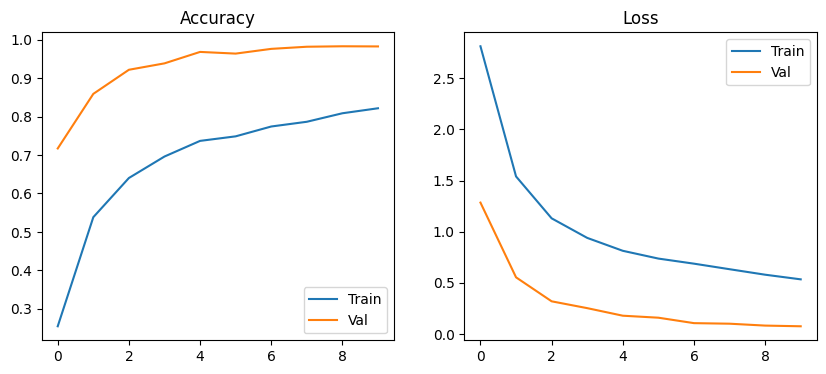

In [ ]:
# ============================================================
# 3. BUILD, TRAIN, AND EVALUATE CNN MODEL
# ============================================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make sure these exist from your previous code:
# IMG_SIZE, X_train, X_test, y_train, y_test, num_classes, label_encoder

# Data augmentation (same as your earlier setup)
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1
)
datagen.fit(X_train)

# =======================
# BUILD SIMPLE CNN MODEL
# =======================
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 1))

x = Conv2D(32, (3,3), activation='relu')(inputs)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), activation='relu', name='conv2d_last')(x)
x = MaxPooling2D(2,2)(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# =======================
# TRAIN MODEL
# =======================
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)

# =======================
# EVALUATE MODEL
# =======================
loss, acc = model.evaluate(X_test, y_test, verbose=0)
total_accuracy = acc * 100

display(HTML(f"<h3 style='color:yellow;'>✅ Total CNN Accuracy: {total_accuracy:.2f}%</h3>"))

# =======================
# CLASSIFICATION REPORT
# =======================
y_pred = model.predict(X_test, verbose=0)
y_true = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

report = classification_report(
    y_true, y_pred_labels,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

# =======================
# PLOTS
# =======================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')

plt.title('Loss'); plt.legend()

plt.show()
# ============================================================


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

🎯 Predicted class: No Overtaking for Trucks

🔍 Generating SHAP explanation (please wait)...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_9
Received: inputs=['Tensor(shape=(1, 48, 48, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_9
Received: inputs=['Tensor(shape=(50, 48, 48, 1))']
  warnings.warn(msg)


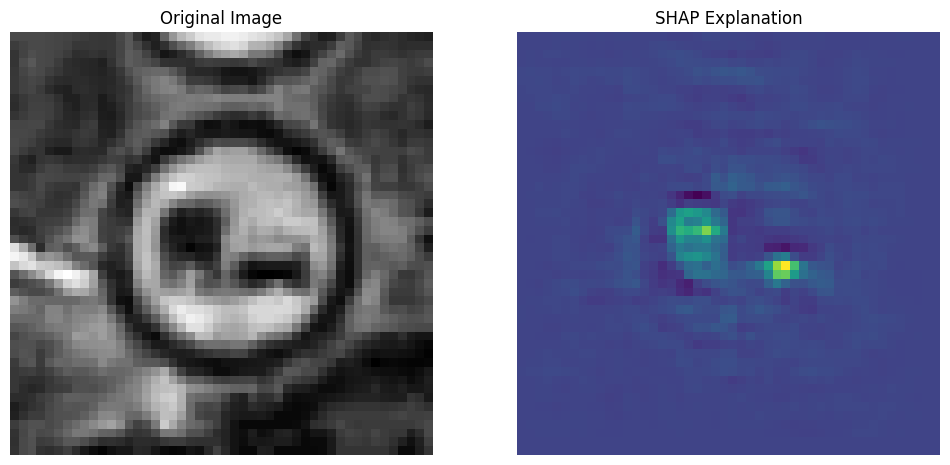


🔍 Generating LIME explanation...


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━

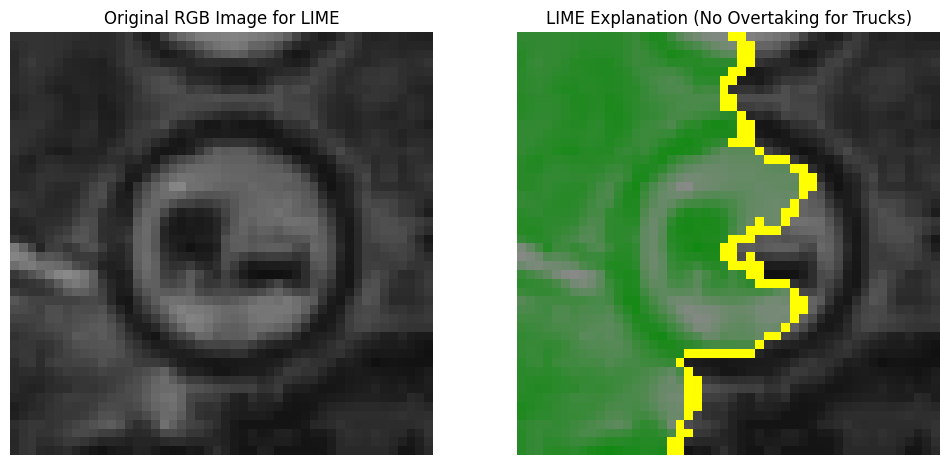


🔥 Generating Grad-CAM explanation...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_9']]
Received: inputs=Tensor(shape=(1, 48, 48, 1))
  warnings.warn(msg)


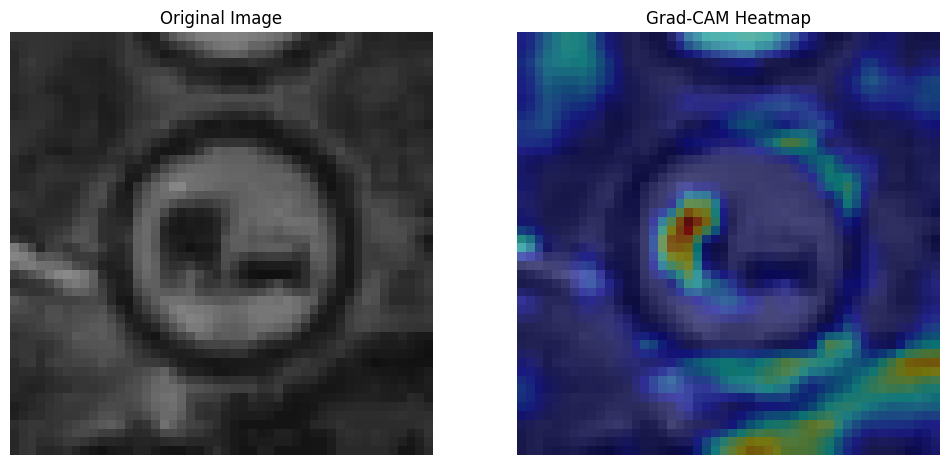


✅ Model and label classes saved successfully!


In [ ]:
# ============================================================
# 4. EXPLAINABILITY: SHAP & LIME (FINAL FIXED)
# ============================================================
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import random

# Pick a random test image
idx = random.randint(0, len(X_test) - 1)
test_img = X_test[idx]
pred = model.predict(np.expand_dims(test_img, axis=0))
pred_class = np.argmax(pred)
pred_class_name = label_encoder.inverse_transform([pred_class])[0]
print(f"\n🎯 Predicted class: {pred_class_name}")

# ============================================================
# --- SHAP EXPLANATION ---
# ============================================================
print("\n🔍 Generating SHAP explanation (please wait)...")

background = X_train[np.random.choice(X_train.shape[0], 30, replace=False)]

explainer = shap.GradientExplainer(model, background)

test_img_expanded = np.expand_dims(test_img, axis=0)
shap_values = explainer.shap_values(test_img_expanded)

if isinstance(shap_values, list):
    shap_val = shap_values[min(pred_class, len(shap_values) - 1)][0]
else:
    shap_val = shap_values[0]

if shap_val.ndim == 4:
    shap_val = shap_val[..., pred_class]

sv = (shap_val - shap_val.min()) / (shap_val.max() - shap_val.min() + 1e-8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(test_img.squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sv)
plt.title("SHAP Explanation")
plt.axis('off')
plt.show()

# ============================================================
# --- LIME EXPLANATION (FIXED FOR GRAYSCALE IMAGES) ---
# ============================================================
print("\n🔍 Generating LIME explanation...")
explainer_lime = lime_image.LimeImageExplainer()

# Convert grayscale → RGB
test_img_rgb = np.stack([test_img.squeeze()] * 3, axis=-1)

def predict_fn(imgs):
    imgs = np.array(imgs, dtype=np.float32)

    # Convert LIME's RGB images → grayscale for the CNN
    imgs_gray = np.mean(imgs, axis=-1, keepdims=True)

    if imgs_gray.max() > 1:
        imgs_gray = imgs_gray / 255.0

    return model.predict(imgs_gray)

explanation = explainer_lime.explain_instance(
    (test_img_rgb * 255).astype(np.uint8),
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=500
)

temp, mask = explanation.get_image_and_mask(
    label=pred_class,
    positive_only=False,
    hide_rest=False,
    num_features=8,
    min_weight=0.05
)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(test_img_rgb)
ax[0].set_title("Original RGB Image for LIME")
ax[0].axis('off')

ax[1].imshow(mark_boundaries(temp / 255.0, mask))
ax[1].set_title(f"LIME Explanation ({pred_class_name})")
ax[1].axis('off')
plt.show()

# ============================================================
# 7. GRAD-CAM EXPLANATION (FINAL FIXED, CLEAN)
# ============================================================
print("\n🔥 Generating Grad-CAM explanation...")

import tensorflow as tf
import matplotlib.cm as cm
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)

    return heatmap

def overlay_gradcam(heatmap, img, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    superimposed = heatmap * alpha + img.astype(np.float32) * (1 - alpha)

    return np.uint8(superimposed)

last_conv_layer_name = [
    layer.name for layer in model.layers if 'conv2d' in layer.name
][-1]

img_input = np.expand_dims(test_img, axis=0)
heatmap = get_gradcam_heatmap(img_input, model, last_conv_layer_name)

orig_img = (test_img.squeeze() * 255).astype(np.uint8)
orig_img_rgb = np.stack([orig_img] * 3, axis=-1)

gradcam_img = overlay_gradcam(heatmap, orig_img_rgb)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(orig_img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gradcam_img)
plt.title("Grad-CAM Heatmap")
plt.axis('off')
plt.show()

# ============================================================
# 5. SAVE MODEL
# ============================================================
model.save("traffic_sign_model_gtsrb.h5")
np.save("label_classes_gtsrb.npy", label_encoder.classes_)
print("\n✅ Model and label classes saved successfully!")

# ============================================================
# PREDICTION FUNCTION
# ============================================================
def predict_image(img_path, top_k=3, show_image=True):
    """
    Predict the traffic sign in the given image path.
    """

    img = cv2.imread(img_path)

    if img is None:
        print(f"❌ ERROR: Cannot load image at: {img_path}")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_normalized = img_resized.astype("float32") / 255.0
    img_input = np.expand_dims(img_normalized.mean(axis=-1, keepdims=True), axis=0)

    preds = model.predict(img_input, verbose=0)[0]
    class_idx = np.argmax(preds)
    confidence = preds[class_idx]

    try:
        class_name = label_encoder.inverse_transform([class_idx])[0]
    except Exception as e:
        print("❌ Label decoding error:", e)
        return None

    if show_image:
        plt.figure(figsize=(5, 5))
        plt.imshow(img_resized)
        plt.title(f"Predicted: {class_name} ({confidence*100:.2f}%)")
        plt.axis('off')
        plt.show()

    print("\n🔍 **Top Predictions:**")
    top_indices = preds.argsort()[-top_k:][::-1]

    for i in top_indices:
        name = label_encoder.inverse_transform([i])[0]
        print(f"  → {name:<20} : {preds[i]*100:.2f}%")

    print(f"\n✅ Final Predicted Sign: **{class_name}**")
    print(f"✔ Confidence: {confidence*100:.2f}%\n")

    return class_name
